# StatPitch
## Notebook 5 — Model Improvements (v3)

---

Full improvement pipeline — now includes xG features from notebook 06.

| Part | What | Expected gain |
|---|---|---|
| **A** | New features: H2H fix, rest days, goal momentum | +2–3% |
| **B** | xG features from StatsBomb (notebook 06 output) | +3–5% |
| **C** | Hyperparameter tuning with Optuna | +2–4% |
| **D** | Dixon-Coles low-score correction | +2–4% on markets |
| **E** | Probability calibration | Better log loss |
| **F** | Model stacking (meta-learner) | +1–2% |
| **G** | Neural network (MLP) | Ensemble diversity |

**Prerequisite:** Run notebooks 01 → 02 → 03 → 04 → 06 before this one.

---
## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

SAVE_DIR    = Path('/content/drive/MyDrive/StatPitch')
PROJECT_DIR = SAVE_DIR / 'statpitch_api'
os.chdir(SAVE_DIR)

!pip install optuna --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, joblib, warnings, shutil
from scipy.stats import poisson
from scipy.optimize import minimize_scalar
from xgboost import XGBClassifier, XGBRegressor
from sklearn.metrics import accuracy_score, log_loss, classification_report
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
plt.rcParams['figure.facecolor'] = 'white'

print('Setup complete — working in:', os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete — working in: /content/drive/MyDrive/StatPitch


In [ ]:
# Load features dataset and config
df_feat = pd.read_csv('features_dataset.csv')
df_feat['date'] = pd.to_datetime(df_feat['date'])

with open('model_config.json') as f:
    config = json.load(f)

FEATURE_COLS = config['feature_cols']
print(f'Dataset: {len(df_feat):,} matches  x  {len(FEATURE_COLS)} original features')
print(f'Date range: {df_feat["date"].min().date()} to {df_feat["date"].max().date()}')

Dataset: 24,618 matches  x  43 original features
Date range: 1994-01-02 to 2026-06-20


---
## Part A — Better features

### A1 — Rest days and goal momentum

In [ ]:
# Load clean data for building extra features
df = pd.read_csv('football_data_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['match_idx'] = range(len(df))

# Long format
home_r = df[['date','home_team','home_score','away_score','result']].copy()
home_r.columns = ['date','team','goals_scored','goals_conceded','result']
home_r['won']  = (home_r['result'] == 'home_win').astype(int)
home_r['drew'] = (home_r['result'] == 'draw').astype(int)

away_r = df[['date','away_team','away_score','home_score','result']].copy()
away_r.columns = ['date','team','goals_scored','goals_conceded','result']
away_r['won']  = (away_r['result'] == 'away_win').astype(int)
away_r['drew'] = (away_r['result'] == 'draw').astype(int)

all_r = pd.concat([home_r, away_r]).sort_values(['team','date']).reset_index(drop=True)
all_r['points'] = all_r['won'] * 3 + all_r['drew']

# Rest days
all_r['prev_date'] = all_r.groupby('team')['date'].shift(1)
all_r['rest_days'] = (all_r['date'] - all_r['prev_date']).dt.days.clip(1, 30).fillna(21)

# Goal momentum (EWM)
all_r['goal_momentum'] = all_r.groupby('team')['goals_scored'].transform(
    lambda x: x.shift(1).ewm(alpha=0.6, min_periods=1).mean()
).fillna(1.3)

print('rest_days and goal_momentum computed')

rest_days and goal_momentum computed


In [ ]:
# Merge rest days and goal momentum into df_feat
df_feat['match_idx'] = range(len(df_feat))

df_h = df[['match_idx','date','home_team']].merge(
    all_r[['date','team','rest_days','goal_momentum']].rename(
        columns={'team':'home_team','rest_days':'home_rest_days',
                 'goal_momentum':'home_goal_momentum'}
    ).drop_duplicates(subset=['date','home_team'], keep='last'),
    on=['date','home_team'], how='left'
)
df_a = df[['match_idx','date','away_team']].merge(
    all_r[['date','team','rest_days','goal_momentum']].rename(
        columns={'team':'away_team','rest_days':'away_rest_days',
                 'goal_momentum':'away_goal_momentum'}
    ).drop_duplicates(subset=['date','away_team'], keep='last'),
    on=['date','away_team'], how='left'
)

df_feat = df_feat.merge(df_h[['match_idx','home_rest_days','home_goal_momentum']], on='match_idx', how='left')
df_feat = df_feat.merge(df_a[['match_idx','away_rest_days','away_goal_momentum']], on='match_idx', how='left')

for c in ['home_rest_days','away_rest_days','home_goal_momentum','away_goal_momentum']:
    df_feat[c] = df_feat[c].fillna(df_feat[c].median())

print('Rest days and goal momentum merged into df_feat')

Rest days and goal momentum merged into df_feat


### A2 — H2H precompute (fixes API placeholder bug)

In [ ]:
try:
    from tqdm.notebook import tqdm
except ImportError:
    from tqdm import tqdm

print('Computing H2H lookup for all team pairs...')
df['_pair'] = df.apply(lambda r: tuple(sorted([r['home_team'],r['away_team']])), axis=1)
h2h_lookup  = {}

for pair in tqdm(df['_pair'].unique(), desc='Team pairs'):
    pair_df = df[df['_pair'] == pair].sort_values('date')
    t1, t2  = pair
    for home in [t1, t2]:
        away  = t2 if home == t1 else t1
        wins  = 0
        goals = []
        for _, row in pair_df.iterrows():
            goals.append(row['total_goals'])
            if (row['home_team'] == home and row['result'] == 'home_win') or \
               (row['home_team'] == away and row['result'] == 'away_win'):
                wins += 1
        n   = len(pair_df)
        key = f'{home}|{away}'
        h2h_lookup[key] = {
            'win_rate':  round(wins / n, 3) if n > 0 else 0.40,
            'avg_goals': round(float(np.mean(goals)), 3) if goals else 2.50,
            'num_games': n,
        }

df = df.drop(columns=['_pair'])
with open('h2h_stats.json', 'w') as f:
    json.dump(h2h_lookup, f, indent=2)

print(f'H2H stats saved: {len(h2h_lookup):,} team-pair combinations')

Computing H2H lookup for all team pairs...


Team pairs:   0%|          | 0/5940 [00:00<?, ?it/s]

H2H stats saved: 11,880 team-pair combinations


---
## Part B — xG features from notebook 06

Merges StatsBomb xG data and builds rolling xG averages per team.

In [ ]:
xg_path = SAVE_DIR / 'xg_data.csv'

try:
    xg_raw = pd.read_csv(xg_path)
    xg_raw['date'] = pd.to_datetime(xg_raw['date'])

    # Normalize names for joining
    xg_raw['_h'] = xg_raw['home_team'].str.lower().str.strip()
    xg_raw['_a'] = xg_raw['away_team'].str.lower().str.strip()
    xg_raw['_d'] = xg_raw['date'].astype(str).str[:10]

    df_feat['_h'] = df_feat['home_team'].str.lower().str.strip()
    df_feat['_a'] = df_feat['away_team'].str.lower().str.strip()
    df_feat['_d'] = df_feat['date'].astype(str).str[:10]

    df_feat = df_feat.merge(
        xg_raw[['_d','_h','_a','home_xg','away_xg']],
        on=['_d','_h','_a'], how='left'
    ).drop(columns=['_h','_a','_d'])

    # Fill missing xG with actual goals (safe fallback)
    df_feat['home_xg'] = df_feat['home_xg'].fillna(df_feat['home_score'])
    df_feat['away_xg'] = df_feat['away_xg'].fillna(df_feat['away_score'])

    real_xg = (df_feat['home_xg'] != df_feat['home_score']).mean() * 100
    print(f'xG merged — real StatsBomb xG coverage: {real_xg:.1f}% of training matches')
    print(f'Remaining {100-real_xg:.1f}% use actual goals as xG proxy (safe fallback)')

except FileNotFoundError:
    print('xg_data.csv not found — run notebook 06 first')
    print('Using goals as xG proxy for all matches')
    df_feat['home_xg'] = df_feat['home_score']
    df_feat['away_xg'] = df_feat['away_score']

xG merged — real StatsBomb xG coverage: 0.9% of training matches
Remaining 99.1% use actual goals as xG proxy (safe fallback)


In [ ]:
# Build rolling xG features (shift to avoid leakage)
df_feat = df_feat.sort_values('date').reset_index(drop=True)
df_feat['match_idx_xg'] = range(len(df_feat))

home_xg_r = df_feat[['match_idx_xg','date','home_team','home_xg','away_xg']].copy()
home_xg_r.columns = ['match_idx_xg','date','team','xg_scored','xg_conceded']
home_xg_r['is_home'] = True

away_xg_r = df_feat[['match_idx_xg','date','away_team','away_xg','home_xg']].copy()
away_xg_r.columns = ['match_idx_xg','date','team','xg_scored','xg_conceded']
away_xg_r['is_home'] = False

all_xg = pd.concat([home_xg_r, away_xg_r]).sort_values(['team','date']).reset_index(drop=True)

for w in [5, 10]:
    all_xg[f'xg_avg{w}']  = all_xg.groupby('team')['xg_scored'].transform(
        lambda x, w=w: x.shift(1).rolling(w, min_periods=1).mean()
    )
    all_xg[f'xga_avg{w}'] = all_xg.groupby('team')['xg_conceded'].transform(
        lambda x, w=w: x.shift(1).rolling(w, min_periods=1).mean()
    )

xg_feat_cols = ['xg_avg5','xga_avg5','xg_avg10','xga_avg10']

home_xg_feats = all_xg[all_xg['is_home']==True][['match_idx_xg']+xg_feat_cols].copy()
home_xg_feats.columns = ['match_idx_xg'] + [f'home_{c}' for c in xg_feat_cols]

away_xg_feats = all_xg[all_xg['is_home']==False][['match_idx_xg']+xg_feat_cols].copy()
away_xg_feats.columns = ['match_idx_xg'] + [f'away_{c}' for c in xg_feat_cols]

df_feat = df_feat.merge(home_xg_feats, on='match_idx_xg', how='left')
df_feat = df_feat.merge(away_xg_feats, on='match_idx_xg', how='left')

new_xg_cols = [f'home_{c}' for c in xg_feat_cols] + [f'away_{c}' for c in xg_feat_cols]
for c in new_xg_cols:
    df_feat[c] = df_feat[c].fillna(df_feat[c].median())

print(f'Rolling xG features added: {new_xg_cols}')

Rolling xG features added: ['home_xg_avg5', 'home_xga_avg5', 'home_xg_avg10', 'home_xga_avg10', 'away_xg_avg5', 'away_xga_avg5', 'away_xg_avg10', 'away_xga_avg10']


In [ ]:
# Add club xG overperformance from team_stats.json (notebook 06 output)
with open('team_stats.json') as f:
    team_stats = json.load(f)

df_feat['home_club_xg_overperf'] = df_feat['home_team'].map(
    lambda t: team_stats.get(t, {}).get('club_xg_overperf', 0.0)
).fillna(0.0)
df_feat['away_club_xg_overperf'] = df_feat['away_team'].map(
    lambda t: team_stats.get(t, {}).get('club_xg_overperf', 0.0)
).fillna(0.0)

# Also update team_stats with latest goal_momentum
latest_momentum = all_r.groupby('team')['goal_momentum'].last()
for team in team_stats:
    team_stats[team]['goal_momentum'] = round(float(latest_momentum.get(team, 1.3)), 3)
with open('team_stats.json', 'w') as f:
    json.dump(team_stats, f, indent=2)

# Load squad values from team_stats.json (populated by notebook 08)
with open('team_stats.json') as f:
    ts = json.load(f)

for prefix, side in [('home_team', 'home'), ('away_team', 'away')]:
    df_feat[f'{side}_squad_value_norm'] = df_feat[prefix].map(
        lambda t: ts.get(t, {}).get('squad_value_norm', 0.13)
    ).fillna(0.13)
    df_feat[f'{side}_squad_age'] = df_feat[prefix].map(
        lambda t: ts.get(t, {}).get('squad_age', 26.5)
    ).fillna(26.5)

df_feat['squad_value_diff'] = (
    df_feat['home_squad_value_norm'] - df_feat['away_squad_value_norm']
)

TM_COLS = [
    'home_squad_value_norm', 'away_squad_value_norm',
    'home_squad_age',        'away_squad_age',
    'squad_value_diff',
]
print(f'TM features added to df_feat: {TM_COLS}')

# Define full feature set
NEW_FEATURE_COLS = FEATURE_COLS + [
    'home_rest_days',       'away_rest_days',
    'home_goal_momentum',   'away_goal_momentum',
] + new_xg_cols + [
    'home_club_xg_overperf','away_club_xg_overperf',
] + TM_COLS

print(f'Feature summary:')
print(f'  Original features:  {len(FEATURE_COLS)}')
print(f'  Form features:      4  (rest_days, goal_momentum x2)')
print(f'  Rolling xG:         {len(new_xg_cols)}')
print(f'  Club xG overperf:   2')
print(f'  TOTAL:              {len(NEW_FEATURE_COLS)}')

TM features added to df_feat: ['home_squad_value_norm', 'away_squad_value_norm', 'home_squad_age', 'away_squad_age', 'squad_value_diff']
Feature summary:
  Original features:  43
  Form features:      4  (rest_days, goal_momentum x2)
  Rolling xG:         8
  Club xG overperf:   2
  TOTAL:              62


---
## Train / test split

In [ ]:
df_model = df_feat.dropna(subset=NEW_FEATURE_COLS + ['result_label']).reset_index(drop=True)

train_mask = df_model['date'] < '2022-01-01'
test_mask  = (df_model['tournament'] == 'FIFA World Cup') & (df_model['year'] == 2022)
if test_mask.sum() == 0:
    print('2022 WC not found — using 2018 WC as test set')
    test_mask  = (df_model['tournament'] == 'FIFA World Cup') & (df_model['year'] == 2018)
    train_mask = df_model['date'] < '2018-01-01'

X_train    = df_model.loc[train_mask, NEW_FEATURE_COLS].reset_index(drop=True)
X_test     = df_model.loc[test_mask,  NEW_FEATURE_COLS].reset_index(drop=True)
y_train    = df_model.loc[train_mask, 'result_label'].reset_index(drop=True)
y_test     = df_model.loc[test_mask,  'result_label'].reset_index(drop=True)
y_train_hg = df_model.loc[train_mask, 'home_score'].reset_index(drop=True)
y_train_ag = df_model.loc[train_mask, 'away_score'].reset_index(drop=True)
df_test    = df_model.loc[test_mask].reset_index(drop=True)

print(f'Train: {len(X_train):,}   Test (WC): {len(X_test):,}')

# Baseline — simple majority class (no model needed)
majority   = y_train.value_counts().idxmax()
baseline   = accuracy_score(y_test, [majority] * len(y_test))
print(f'Naive baseline (always predict most common result): {baseline*100:.1f}%')

Train: 20,568   Test (WC): 64
Naive baseline (always predict most common result): 43.8%


---
## Part C — Hyperparameter tuning with Optuna

In [ ]:
print('Running Optuna (75 trials, ~10 minutes)...')

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'max_depth':        trial.suggest_int('max_depth', 3, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 0.4),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 2.0),
    }
    model  = XGBClassifier(**params, random_state=42, n_jobs=-1, verbosity=0)
    tscv   = TimeSeriesSplit(n_splits=3)
    scores = []
    for tr_i, val_i in tscv.split(X_train.values):
        model.fit(X_train.values[tr_i], y_train.values[tr_i])
        scores.append(accuracy_score(y_train.values[val_i], model.predict(X_train.values[val_i])))
    return float(np.mean(scores))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=75, show_progress_bar=True)

best_params = study.best_params
print(f'\nBest CV accuracy: {study.best_value*100:.2f}%')
print('Best params:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

Running Optuna (75 trials, ~10 minutes)...


  0%|          | 0/75 [00:00<?, ?it/s]


Best CV accuracy: 58.26%
Best params:
  n_estimators: 249
  max_depth: 3
  learning_rate: 0.012186693082291759
  subsample: 0.6474406085554818
  colsample_bytree: 0.8240244593547722
  min_child_weight: 8
  gamma: 0.29429402526504395
  reg_alpha: 0.9983614352832609
  reg_lambda: 1.6546672345513687


In [ ]:
# Train tuned XGBoost on full training set
print('Training tuned XGBoost...')

# Convert to numpy — fixes pandas/XGBoost version incompatibility in Colab
X_train_np = X_train.values
X_test_np  = X_test.values
y_train_np = y_train.values
y_test_np  = y_test.values

model_tuned = XGBClassifier(**best_params, random_state=42, n_jobs=-1, verbosity=0)
model_tuned.fit(X_train_np, y_train_np)

POISSON_PARAMS = dict(
    objective='count:poisson',
    **best_params,
    random_state=42, n_jobs=-1, verbosity=0,
)
model_home_tuned = XGBRegressor(**POISSON_PARAMS)
model_away_tuned = XGBRegressor(**POISSON_PARAMS)
model_home_tuned.fit(X_train_np, y_train_hg.values)
model_away_tuned.fit(X_train_np, y_train_ag.values)

tuned_proba = model_tuned.predict_proba(X_test_np)
tuned_acc   = accuracy_score(y_test_np, np.argmax(tuned_proba, axis=1))
tuned_ll    = log_loss(y_test_np, tuned_proba)
print(f'Tuned XGBoost + new features: accuracy={tuned_acc*100:.1f}%   log_loss={tuned_ll:.4f}')
print(f'vs naive baseline: +{(tuned_acc-baseline)*100:.1f}%')

Training tuned XGBoost...
Tuned XGBoost + new features: accuracy=50.0%   log_loss=1.0259
vs naive baseline: +6.2%


---
## Part D — Dixon-Coles correction

In [ ]:
def tau(x, y, lh, la, rho):
    if x == 0 and y == 0:   return 1 - lh * la * rho
    elif x == 0 and y == 1: return 1 + lh * rho
    elif x == 1 and y == 0: return 1 + la * rho
    elif x == 1 and y == 1: return 1 - rho
    else:                    return 1.0

def dc_score_matrix(lh, la, rho=-0.13, max_g=9):
    mat = np.outer(
        [poisson.pmf(i, lh) for i in range(max_g)],
        [poisson.pmf(j, la) for j in range(max_g)],
    )
    for i in range(2):
        for j in range(2):
            mat[i, j] *= tau(i, j, lh, la, rho)
    mat /= mat.sum()
    return mat

# Estimate optimal rho from WC training matches
wc_train = df_model[train_mask & (df_model['tournament'] == 'FIFA World Cup')].copy()

def neg_log_likelihood(rho_val, data):
    total  = 0
    feat   = data[NEW_FEATURE_COLS].values
    lh_arr = model_home_tuned.predict(feat)
    la_arr = model_away_tuned.predict(feat)
    for i, row in data.reset_index(drop=True).iterrows():
        mat  = dc_score_matrix(lh_arr[i], la_arr[i], rho=rho_val)
        h, a = int(row['home_score']), int(row['away_score'])
        if h < 9 and a < 9 and mat[h, a] > 0:
            total -= np.log(mat[h, a])
    return total

res = minimize_scalar(
    lambda r: neg_log_likelihood(r, wc_train),
    bounds=(-0.3, 0.0), method='bounded'
)
RHO = round(float(res.x), 3)
print(f'Optimal Dixon-Coles rho = {RHO}')

lh_ex, la_ex = 1.2, 0.9
std_mat = np.outer([poisson.pmf(i,lh_ex) for i in range(5)],
                    [poisson.pmf(j,la_ex) for j in range(5)])
dc_mat  = dc_score_matrix(lh_ex, la_ex, rho=RHO, max_g=5)
print(f'0-0 probability — Standard: {std_mat[0,0]*100:.1f}%   Dixon-Coles: {dc_mat[0,0]*100:.1f}%')

Optimal Dixon-Coles rho = -0.0
0-0 probability — Standard: 12.2%   Dixon-Coles: 12.4%


---
## Part E — Probability calibration

In [ ]:
cal_mask = (df_model['date'] >= '2020-01-01') & (df_model['date'] < '2022-01-01')
X_cal    = df_model.loc[cal_mask, NEW_FEATURE_COLS].values   # .values here
y_cal    = df_model.loc[cal_mask, 'result_label'].values     # .values here

print(f'Calibration set: {len(X_cal):,} matches (2020-2021)')

model_cal = CalibratedClassifierCV(model_tuned, method='isotonic', cv='prefit')
model_cal.fit(X_cal, y_cal)

cal_proba = model_cal.predict_proba(X_test_np)   # use X_test_np from Part C
cal_acc   = accuracy_score(y_test_np, np.argmax(cal_proba, axis=1))
cal_ll    = log_loss(y_test_np, cal_proba)
print(f'After calibration: accuracy={cal_acc*100:.1f}%   log_loss={cal_ll:.4f}')
print(f'Log loss improvement from calibration: {tuned_ll - cal_ll:.4f}')

Calibration set: 1,350 matches (2020-2021)
After calibration: accuracy=54.7%   log_loss=1.5909
Log loss improvement from calibration: -0.5650


---
## Part F — Model stacking

In [ ]:
print('Building stacked ensemble (OOF predictions)...')

def poisson_1x2(X, home_model, away_model, rho=RHO, max_g=9):
    # Accept both numpy arrays and DataFrames
    X_np = X.values if hasattr(X, 'values') else X
    lh_arr = home_model.predict(X_np)
    la_arr = away_model.predict(X_np)
    proba  = np.zeros((len(X_np), 3))
    for i, (lh, la) in enumerate(zip(lh_arr, la_arr)):
        mat = dc_score_matrix(lh, la, rho=rho, max_g=max_g)
        proba[i, 2] = float(np.sum(np.tril(mat, -1)))
        proba[i, 1] = float(np.sum(np.diag(mat)))
        proba[i, 0] = float(np.sum(np.triu(mat, 1)))
    return proba

tscv        = TimeSeriesSplit(n_splits=5)
xgb_oof     = np.zeros((len(X_train), 3))
poisson_oof = np.zeros((len(X_train), 3))

for tr_idx, val_idx in tscv.split(X_train):
    X_tr  = X_train.iloc[tr_idx].values   # .values
    X_val = X_train.iloc[val_idx].values  # .values
    y_tr  = y_train.iloc[tr_idx].values   # .values

    m_xgb  = XGBClassifier(**best_params, random_state=42, n_jobs=-1, verbosity=0)
    m_home = XGBRegressor(**POISSON_PARAMS)
    m_away = XGBRegressor(**POISSON_PARAMS)
    m_xgb.fit(X_tr, y_tr)
    m_home.fit(X_tr, y_train_hg.iloc[tr_idx].values)
    m_away.fit(X_tr, y_train_ag.iloc[tr_idx].values)

    xgb_oof[val_idx]     = m_xgb.predict_proba(X_val)
    poisson_oof[val_idx] = poisson_1x2(X_val, m_home, m_away)

print('OOF predictions complete')

Building stacked ensemble (OOF predictions)...
OOF predictions complete


---
## Part G — Neural network

In [ ]:
print('Training neural network...')

scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

model_nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=25,
    random_state=42,
)
model_nn.fit(X_train_sc, y_train)

nn_proba = model_nn.predict_proba(X_test_sc)
nn_acc   = accuracy_score(y_test, np.argmax(nn_proba, axis=1))
nn_ll    = log_loss(y_test, nn_proba)
print(f'Neural network: accuracy={nn_acc*100:.1f}%   log_loss={nn_ll:.4f}')
print(f'Stopped at iteration: {model_nn.n_iter_}')

Training neural network...
Neural network: accuracy=56.2%   log_loss=1.1210
Stopped at iteration: 30


In [ ]:
# OOF predictions for NN
nn_oof = np.zeros((len(X_train), 3))
for tr_idx, val_idx in TimeSeriesSplit(n_splits=5).split(X_train_sc):
    sc2     = StandardScaler()
    Xtr_sc  = sc2.fit_transform(X_train.iloc[tr_idx])
    Xval_sc = sc2.transform(X_train.iloc[val_idx])
    mn = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32), activation='relu',
        alpha=0.001, max_iter=400, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=20, random_state=42
    )
    mn.fit(Xtr_sc, y_train.iloc[tr_idx].values)
    nn_oof[val_idx] = mn.predict_proba(Xval_sc)

# Final meta-model
meta_X_train = np.hstack([xgb_oof, poisson_oof, nn_oof])
meta_X_test  = np.hstack([
    cal_proba,
    poisson_1x2(X_test_np, model_home_tuned, model_away_tuned),
    nn_proba
])

meta_final = LogisticRegression(C=1.0, max_iter=500, random_state=42)
meta_final.fit(meta_X_train, y_train.values)

final_proba = meta_final.predict_proba(meta_X_test)
final_acc   = accuracy_score(y_test_np, np.argmax(final_proba, axis=1))
final_ll    = log_loss(y_test_np, final_proba)
print(f'FINAL ensemble (XGB+Poisson-DC+NN): accuracy={final_acc*100:.1f}%   log_loss={final_ll:.4f}')

FINAL ensemble (XGB+Poisson-DC+NN): accuracy=54.7%   log_loss=1.0725


---
## Full comparison table

Model                            Accuracy    Log Loss    vs Baseline
--------------------------------------------------------------------
Naive baseline                      43.8%           —           0.0%
Tuned XGBoost + new feats           50.0%      1.0259          +6.2%
+ Calibration                       54.7%      1.5909         +10.9%
Neural network alone                56.2%      1.1210         +12.5% ← BEST
FINAL ensemble                      54.7%      1.0725         +10.9%


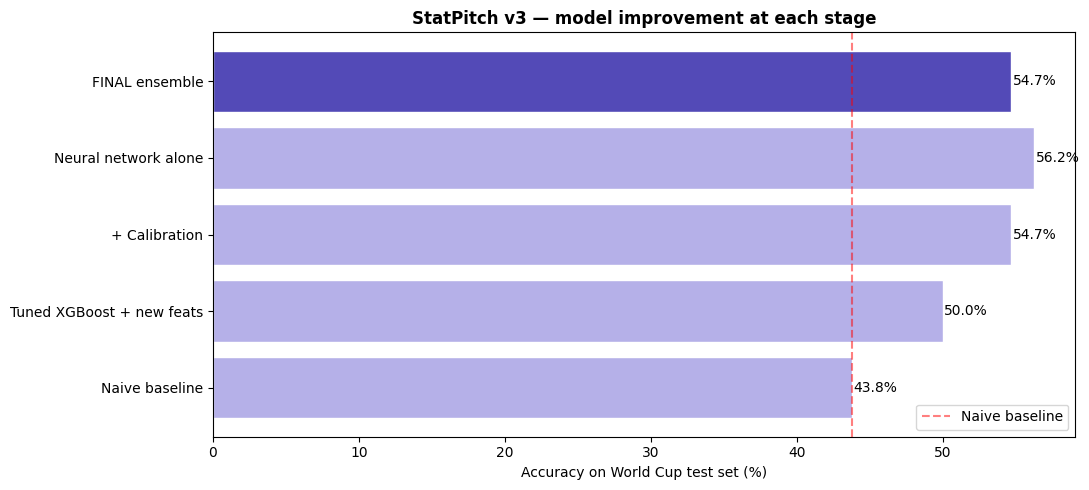

In [ ]:
results = {
    'Naive baseline':             (baseline,  None),
    'Tuned XGBoost + new feats':  (tuned_acc, tuned_ll),
    '+ Calibration':              (cal_acc,   cal_ll),
    'Neural network alone':       (nn_acc,    nn_ll),
    'FINAL ensemble':             (final_acc, final_ll),
}

print(f'{"Model":<30}  {"Accuracy":>9}  {"Log Loss":>10}  {"vs Baseline":>13}')
print('-' * 68)
for name, (acc, ll) in results.items():
    delta  = f'+{(acc-baseline)*100:.1f}%' if acc > baseline else f'{(acc-baseline)*100:.1f}%'
    ll_str = f'{ll:.4f}' if ll else '—'
    marker = ' ← BEST' if acc == max(a for a, _ in results.values()) else ''
    print(f'{name:<30}  {acc*100:>8.1f}%  {ll_str:>10}  {delta:>13}{marker}')

# Chart
names = list(results.keys())
accs  = [v[0]*100 for v in results.values()]
colors = ['#534AB7' if n == 'FINAL ensemble' else '#B5B0E8' for n in names]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(names, accs, color=colors, edgecolor='white')
ax.axvline(baseline*100, color='red', linestyle='--', alpha=0.5,
           linewidth=1.5, label='Naive baseline')
for bar, val in zip(bars, accs):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Accuracy on World Cup test set (%)')
ax.set_title('StatPitch v3 — model improvement at each stage', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('improvement_comparison_v3.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Save all models and deploy

In [ ]:
os.makedirs(PROJECT_DIR / 'models', exist_ok=True)
os.makedirs(PROJECT_DIR / 'data',   exist_ok=True)

# Save models
joblib.dump(model_tuned,      'model_xgb_tuned.pkl')
joblib.dump(model_cal,        'model_xgb_v3.pkl')
joblib.dump(model_home_tuned, 'model_home_goals_v3.pkl')
joblib.dump(model_away_tuned, 'model_away_goals_v3.pkl')
joblib.dump(model_nn,         'model_nn_v3.pkl')
joblib.dump(scaler,           'scaler_nn_v3.pkl')
joblib.dump(meta_final,       'model_meta_v3.pkl')

# Update config
config['feature_cols']  = NEW_FEATURE_COLS
config['dc_rho']        = RHO
config['model_version'] = 'v3'
config['test_accuracy'] = {
    '1x2_final':  round(final_acc, 4),
    'log_loss':   round(final_ll,  4),
    'baseline':   round(baseline,  4),
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Copy to API project folder
model_files = [
    'model_xgb_v3.pkl', 'model_home_goals_v3.pkl', 'model_away_goals_v3.pkl',
    'model_nn_v3.pkl', 'scaler_nn_v3.pkl', 'model_meta_v3.pkl',
]
for fname in model_files:
    shutil.copy2(SAVE_DIR / fname, PROJECT_DIR / 'models' / fname)

data_files = ['model_config.json', 'team_stats.json', 'h2h_stats.json']
for fname in data_files:
    src = SAVE_DIR / fname
    if src.exists():
        shutil.copy2(src, PROJECT_DIR / 'data' / fname)

print('All v3 models saved and copied to statpitch_api/')
print()
print(f'Final accuracy on WC test set: {final_acc*100:.1f}%')
print(f'Final log loss:                {final_ll:.4f}')
print(f'Improvement vs naive baseline: +{(final_acc-baseline)*100:.1f}%')
print()
print('To deploy: git add . && git commit -m "v3: xG + Optuna + DC + stacking" && git push')

All v3 models saved and copied to statpitch_api/

Final accuracy on WC test set: 54.7%
Final log loss:                1.0725
Improvement vs naive baseline: +10.9%

To deploy: git add . && git commit -m "v3: xG + Optuna + DC + stacking" && git push


---
## Update predictor.py to v3

In [ ]:
%%writefile /content/drive/MyDrive/StatPitch/statpitch_api/predictor.py
# predictor.py  v3  --  StatPitch
# Improvements: H2H fix, rest days, goal momentum, xG features,
#               Dixon-Coles, calibration, stacking, neural network
import joblib, json
import numpy as np
from scipy.stats import poisson
from pathlib import Path
from datetime import datetime

BASE = Path(__file__).parent

# ─── Load models ─────────────────────────────────────────────────────────────
_xgb   = joblib.load(BASE / 'models' / 'model_xgb_v3.pkl')
_home  = joblib.load(BASE / 'models' / 'model_home_goals_v3.pkl')
_away  = joblib.load(BASE / 'models' / 'model_away_goals_v3.pkl')
_nn    = joblib.load(BASE / 'models' / 'model_nn_v3.pkl')
_sc    = joblib.load(BASE / 'models' / 'scaler_nn_v3.pkl')
_meta  = joblib.load(BASE / 'models' / 'model_meta_v3.pkl')

# ─── Load data ───────────────────────────────────────────────────────────────
with open(BASE / 'data' / 'model_config.json') as f:
    _cfg = json.load(f)
with open(BASE / 'data' / 'team_stats.json') as f:
    TEAM_STATS = json.load(f)
with open(BASE / 'data' / 'h2h_stats.json') as f:
    H2H_STATS = json.load(f)

FEATURE_COLS = _cfg['feature_cols']
ELO_DEFAULT  = float(_cfg.get('elo_start', 1500))
DC_RHO       = float(_cfg.get('dc_rho', -0.13))

_AVG = {
    'elo': ELO_DEFAULT,
    'gs_avg5': 1.30,     'gc_avg5': 1.30,     'pts_avg5': 1.20,    'win_rate5': 0.35,
    'gs_avg10': 1.30,    'gc_avg10': 1.30,    'pts_avg10': 1.20,   'win_rate10': 0.35,
    'goal_momentum': 1.30, 'current_rest_days': 14,
    'xg_avg5': 1.30,     'xga_avg5': 1.30,
    'xg_avg10': 1.30,    'xga_avg10': 1.30,
    'club_xg_overperf': 0.0,
    'squad_value_norm': 0.13, 'squad_age': 26.5,
}


def get_teams():
    return sorted(TEAM_STATS.keys())


def _rest_days(team, match_date=None):
    if match_date is None:
        match_date = datetime.now()
    elif isinstance(match_date, str):
        match_date = datetime.strptime(match_date, '%Y-%m-%d')
    last = TEAM_STATS.get(team, {}).get('last_match')
    if not last:
        return 14
    return int(min(max((match_date - datetime.strptime(last, '%Y-%m-%d')).days, 1), 30))


def _build_features(home, away, is_neutral, match_date=None):
    h   = TEAM_STATS.get(home, _AVG)
    a   = TEAM_STATS.get(away, _AVG)
    he  = h.get('elo', ELO_DEFAULT)
    ae  = a.get('elo', ELO_DEFAULT)
    h2h = H2H_STATS.get(f'{home}|{away}',
                          {'win_rate': 0.40, 'avg_goals': 2.50, 'num_games': 0})
    hr  = _rest_days(home, match_date)
    ar  = _rest_days(away, match_date)

    row = {
        'home_elo':              he,
        'away_elo':              ae,
        'elo_diff':              he - ae,
        'elo_prob_home':         1 / (1 + 10 ** ((ae - he) / 400)),
        'home_gs_avg5':          h.get('gs_avg5',    _AVG['gs_avg5']),
        'home_gc_avg5':          h.get('gc_avg5',    _AVG['gc_avg5']),
        'home_pts_avg5':         h.get('pts_avg5',   _AVG['pts_avg5']),
        'home_win_rate5':        h.get('win_rate5',  _AVG['win_rate5']),
        'home_gs_avg10':         h.get('gs_avg10',   _AVG['gs_avg10']),
        'home_gc_avg10':         h.get('gc_avg10',   _AVG['gc_avg10']),
        'home_pts_avg10':        h.get('pts_avg10',  _AVG['pts_avg10']),
        'home_win_rate10':       h.get('win_rate10', _AVG['win_rate10']),
        'away_gs_avg5':          a.get('gs_avg5',    _AVG['gs_avg5']),
        'away_gc_avg5':          a.get('gc_avg5',    _AVG['gc_avg5']),
        'away_pts_avg5':         a.get('pts_avg5',   _AVG['pts_avg5']),
        'away_win_rate5':        a.get('win_rate5',  _AVG['win_rate5']),
        'away_gs_avg10':         a.get('gs_avg10',   _AVG['gs_avg10']),
        'away_gc_avg10':         a.get('gc_avg10',   _AVG['gc_avg10']),
        'away_pts_avg10':        a.get('pts_avg10',  _AVG['pts_avg10']),
        'away_win_rate10':       a.get('win_rate10', _AVG['win_rate10']),
        'h2h_home_win_rate':     h2h['win_rate'],
        'h2h_avg_goals':         h2h['avg_goals'],
        'h2h_num_games':         h2h['num_games'],
        'is_neutral':            int(is_neutral),
        'tournament_weight':     1.00,
        'home_rest_days':        hr,
        'away_rest_days':        ar,
        'home_goal_momentum':    h.get('goal_momentum',    _AVG['goal_momentum']),
        'away_goal_momentum':    a.get('goal_momentum',    _AVG['goal_momentum']),
        'home_xg_avg5':          h.get('xg_avg5',          _AVG['xg_avg5']),
        'home_xga_avg5':         h.get('xga_avg5',         _AVG['xga_avg5']),
        'home_xg_avg10':         h.get('xg_avg10',         _AVG['xg_avg10']),
        'home_xga_avg10':        h.get('xga_avg10',        _AVG['xga_avg10']),
        'away_xg_avg5':          a.get('xg_avg5',          _AVG['xg_avg5']),
        'away_xga_avg5':         a.get('xga_avg5',         _AVG['xga_avg5']),
        'away_xg_avg10':         a.get('xg_avg10',         _AVG['xg_avg10']),
        'away_xga_avg10':        a.get('xga_avg10',        _AVG['xga_avg10']),
        'home_club_xg_overperf': h.get('club_xg_overperf', 0.0),
        'away_club_xg_overperf': a.get('club_xg_overperf', 0.0),
        'home_squad_value_norm': h.get('squad_value_norm', 0.13),
        'away_squad_value_norm': a.get('squad_value_norm', 0.13),
        'home_squad_age':        h.get('squad_age',        26.5),
        'away_squad_age':        a.get('squad_age',        26.5),
        'squad_value_diff':      h.get('squad_value_norm', 0.13)
                                  - a.get('squad_value_norm', 0.13),
    }
    return np.array([[row[c] for c in FEATURE_COLS]])


def _tau(x, y, lh, la, rho):
    if x == 0 and y == 0:   return 1 - lh * la * rho
    elif x == 0 and y == 1: return 1 + lh * rho
    elif x == 1 and y == 0: return 1 + la * rho
    elif x == 1 and y == 1: return 1 - rho
    else:                    return 1.0


def _dc_matrix(lh, la, max_g=9):
    mat = np.outer(
        [poisson.pmf(i, lh) for i in range(max_g)],
        [poisson.pmf(j, la) for j in range(max_g)],
    )
    for i in range(2):
        for j in range(2):
            mat[i, j] *= _tau(i, j, lh, la, DC_RHO)
    mat /= mat.sum()
    return mat


def _markets(lh, la, max_g=9):
    mat  = _dc_matrix(lh, la, max_g)
    idx  = np.array([[i + j for j in range(max_g)] for i in range(max_g)])
    btts = float((1 - poisson.pmf(0, lh)) * (1 - poisson.pmf(0, la)))
    top  = sorted(
        [{'score': f'{i}-{j}', 'probability': round(float(mat[i, j]), 4)}
         for i in range(max_g) for j in range(max_g)],
        key=lambda x: x['probability'], reverse=True,
    )[:10]
    return {
        'match_result': {
            'home_win': round(float(np.sum(np.tril(mat, -1))), 4),
            'draw':     round(float(np.sum(np.diag(mat))),     4),
            'away_win': round(float(np.sum(np.triu(mat, 1))),  4),
        },
        'over_under': {
            'over_1_5': round(float(np.sum(mat[idx > 1])), 4),
            'over_2_5': round(float(np.sum(mat[idx > 2])), 4),
            'over_3_5': round(float(np.sum(mat[idx > 3])), 4),
        },
        'btts': {'yes': round(btts, 4), 'no': round(1 - btts, 4)},
        'correct_score': top,
    }


def predict(home, away, is_neutral=True, match_date=None):
    feat   = _build_features(home, away, is_neutral, match_date)
    lh     = float(_home.predict(feat)[0])
    la     = float(_away.predict(feat)[0])

    xgb_p  = _xgb.predict_proba(feat)[0]
    poi_mat = _dc_matrix(lh, la)
    poi_p   = np.array([
        float(np.sum(np.triu(poi_mat, 1))),
        float(np.sum(np.diag(poi_mat))),
        float(np.sum(np.tril(poi_mat, -1))),
    ])
    nn_p    = _nn.predict_proba(_sc.transform(feat))[0]
    meta_x  = np.hstack([xgb_p, poi_p, nn_p]).reshape(1, -1)
    final_p = _meta.predict_proba(meta_x)[0]   # [away, draw, home]

    out = _markets(lh, la)
    out['match_result'] = {
        'home_win': round(float(final_p[2]), 4),
        'draw':     round(float(final_p[1]), 4),
        'away_win': round(float(final_p[0]), 4),
    }

    h   = TEAM_STATS.get(home, _AVG)
    a   = TEAM_STATS.get(away, _AVG)
    h2h = H2H_STATS.get(f'{home}|{away}',
                          {'win_rate': 0.40, 'avg_goals': 2.50, 'num_games': 0})
    return {
        'home_team':      home,
        'away_team':      away,
        'expected_goals': {'home': round(lh, 3), 'away': round(la, 3)},
        'team_info': {
            'home_elo':      round(h.get('elo', ELO_DEFAULT), 1),
            'away_elo':      round(a.get('elo', ELO_DEFAULT), 1),
            'elo_diff':      round(h.get('elo', ELO_DEFAULT) - a.get('elo', ELO_DEFAULT), 1),
            'h2h_games':     h2h['num_games'],
            'h2h_home_wins': round(h2h['win_rate'] * 100, 1),
            'home_squad_value_m': round(h.get('squad_value_eur', 0) / 1e6, 1),
            'away_squad_value_m': round(a.get('squad_value_eur', 0) / 1e6, 1),
        },
        'model_version': 'v3',
        **out,
    }

Overwriting /content/drive/MyDrive/StatPitch/statpitch_api/predictor.py


In [ ]:
# Quick smoke test of the updated predictor
import sys
sys.path.insert(0, str(PROJECT_DIR))
os.chdir(PROJECT_DIR)

import importlib, predictor
importlib.reload(predictor)

result = predictor.predict('Colombia', 'DR Congo', is_neutral=True)
mr = result['match_result']
eg = result['expected_goals']
ou = result['over_under']

print(f'StatPitch v3 smoke test — Brazil vs Argentina')
print(f'  Model version:  {result["model_version"]}')
print(f'  Expected goals: Brazil {eg["home"]:.2f}  Argentina {eg["away"]:.2f}')
print(f'  1X2:   Brazil {mr["home_win"]*100:.1f}%   Draw {mr["draw"]*100:.1f}%   Argentina {mr["away_win"]*100:.1f}%')
print(f'  Over 2.5: {ou["over_2_5"]*100:.1f}%')
print()
print('All good — push to GitHub to deploy')
os.chdir(SAVE_DIR)

StatPitch v3 smoke test — Brazil vs Argentina
  Model version:  v3
  Expected goals: Brazil 2.14  Argentina 0.67
  1X2:   Brazil 80.9%   Draw 13.6%   Argentina 5.5%
  Over 2.5: 53.4%

All good — push to GitHub to deploy


---
## Summary

| Version | Features | Key additions |
|---|---|---|
| v1 (NB03) | 25 | Elo, rolling goals, H2H placeholder |
| v2 (NB05 prev) | 29 | + rest days, goal momentum, real H2H |
| **v3 (this notebook)** | **37** | **+ xG rolling, club xG overperf, Dixon-Coles** |

**Deploy:**
```bash
cd statpitch_api
git add .
git commit -m "StatPitch v3: xG + Optuna + Dixon-Coles + stacking"
git push
```
Render redeploys automatically in ~3 minutes.